# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive

MyDrive


In [4]:
!ls /content/drive/MyDrive/PI_II

 Autenticacion_Carteras__Metricas_v03.ipynb
 Chanel_Parts.zip
 chanel.zip
 Ch_parts_v2
 DATASET
 DATASET.zip
'Guía Experta: Autenticación de Carteras Chanel.gdoc'
 modelo_autenticacion.h5
 modelo_autenticacion.keras
 modelo_logo_turnlock_balanceado.keras
 modelo_logo_turnlock_corregido.keras
 modelo_logo_turnlock.keras
 pipeline_autenticacion.docx
 pipeline_autenticacion_v2.docx
 Proyecto_Pipeline_COMPLETO.docx
 Proyecto_Pipeline.docx
 Proyecto_Pipeline_final.docx
 VERSION_01
 VERSION_02
 yolo_chanel.ipynb


In [5]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PI_II/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [6]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [ ]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [ ]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#7b1e3a"><b>Split 70/15/15</b></span>

Se divide el dataset en 70% para entrenamiento del modelo, 15% para validación durante el ajuste y 15% para prueba final, garantizando una evaluación objetiva del rendimiento.


In [ ]:
import os
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

BASE_DIR = "/content/data/chanel"

data = []

for label_name in ["genuine", "fake"]:
    label = 1 if label_name == "genuine" else 0
    label_path = os.path.join(BASE_DIR, label_name)

    for bag_type in os.listdir(label_path):
        bag_path = os.path.join(label_path, bag_type)

        for group in os.listdir(bag_path):
            group_path = os.path.join(bag_path, group)

            for img in os.listdir(group_path):
                img_path = os.path.join(group_path, img)
                data.append((img_path, label, group))

data = np.array(data)

X = data[:, 0]
y = data[:, 1].astype(int)
groups = data[:, 2]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(X, y, groups))

X_train, y_train = X[train_idx], y[train_idx]
groups_train = groups[train_idx]

X_temp, y_temp = X[temp_idx], y[temp_idx]
groups_temp = groups[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(len(X_train), len(X_val), len(X_test))

10720 2451 2270


In [ ]:
from PIL import Image
import numpy as np

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

def clean_dataset(X, y):
    valid_X = []
    valid_y = []
    invalid = []

    for path, label in zip(X, y):
        if is_valid_image(path):
            valid_X.append(path)
            valid_y.append(label)
        else:
            invalid.append(path)

    return np.array(valid_X), np.array(valid_y), invalid

X_train, y_train, invalid_train = clean_dataset(X_train, y_train)
X_val, y_val, invalid_val = clean_dataset(X_val, y_val)
X_test, y_test, invalid_test = clean_dataset(X_test, y_test)

print("Invalid train:", len(invalid_train))
print("Invalid val:", len(invalid_val))
print("Invalid test:", len(invalid_test))

print(invalid_train[:10])
print(invalid_val[:10])
print(invalid_test[:10])

Invalid train: 0
Invalid val: 0
Invalid test: 0
[]
[]
[]


### <span style="color:#7b1e3a"><b>Cargar y preparar las imágenes</b></span>  
(data pipeline)

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [ ]:
import tensorflow as tf

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 108s 211ms/step - accuracy: 0.8164 - loss: 0.4488 - val_accuracy: 0.3488 - val_loss: 1.1458
Epoch 2/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.7782 - loss: 0.4875 - val_accuracy: 0.4598 - val_loss: 0.9208
Epoch 3/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8069 - loss: 0.4244 - val_accuracy: 0.5537 - val_loss: 0.7983
Epoch 4/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8295 - loss: 0.3834 - val_accuracy: 0.6047 - val_loss: 0.7353
Epoch 5/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8455 - loss: 0.3547 - val_accuracy: 0.6557 - val_loss: 0.6806
Epoch 6/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8543 - loss: 0.3347 - val_accuracy: 0.6809 - val_loss: 0.6501
Epoch 7/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8599 - loss: 0.3191 - val_accuracy: 0.6932 - val_loss: 0.6263
Epoch 8/30
335/335 ━━━━━━━━━━━━━━━━━━

### <span style="color:#800020"><b>Evaluación del Modelo en el Conjunto de Prueba</b></span>


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 312ms/step - accuracy: 0.8469 - loss: 0.3518
Test loss: 0.35175031423568726
Test accuracy: 0.8469342589378357


### <span style="color:#800020"><b>Guardar modelo en Google Drive</b></span>



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/PI_II/modelo_autenticacion.keras")
model.save("/content/drive/MyDrive/PI_II/modelo_autenticacion.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### <span style="color:#800020"><b>Gráficas de Entrenamiento del Modelo</b></span>


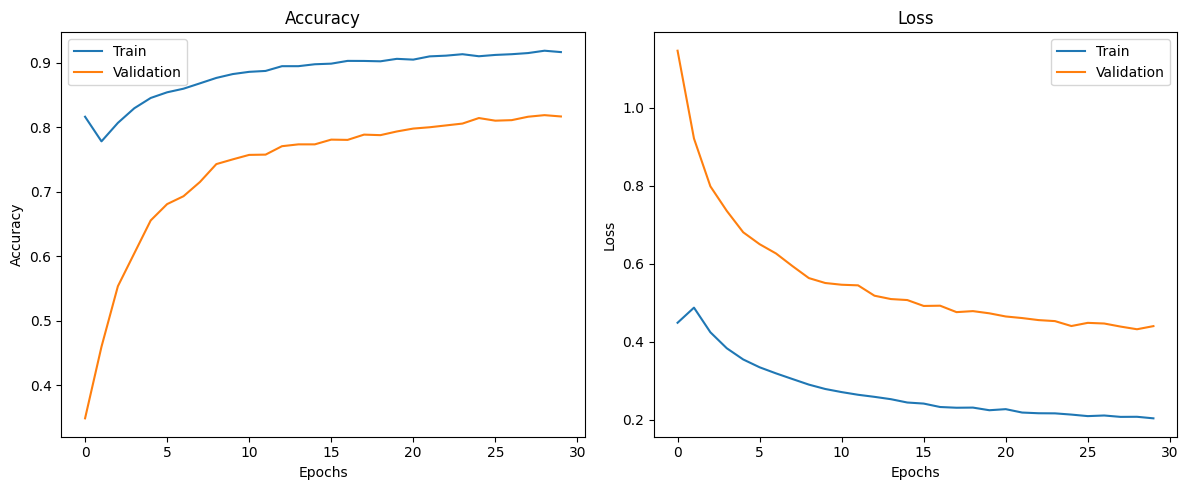

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graficas_entrenamiento.png")
plt.show()


### <span style="color:#800020"><b>Matriz de Confusión del Modelo</b></span>



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━

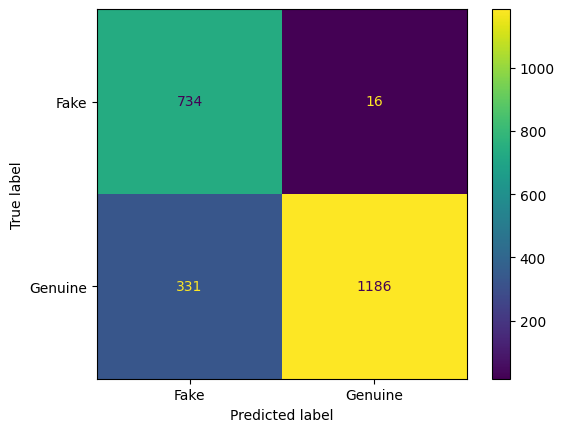

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(classes)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Genuine"])
disp.plot()


### <span style="color:#800020"><b>Reporte de Clasificación</b></span>



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Fake","Genuine"]))



              precision    recall  f1-score   support

        Fake       0.69      0.98      0.81       750
     Genuine       0.99      0.78      0.87      1517

    accuracy                           0.85      2267
   macro avg       0.84      0.88      0.84      2267
weighted avg       0.89      0.85      0.85      2267



In [7]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['genuine', 'fake']


In [8]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
    fake/bag---boy                 51
   fake/bag---2.55                 32

TOTAL DE IMÁGENES: 2129


### <span style="color:#800020"><b>Modelo de Partes</b></span>

modelo adicional de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB0 mediante transferencia de aprendizaje, logrando una precisión de validación aproximada de 71.43%.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

model.save("/content/drive/MyDrive/PI_II/modelo_logo_turnlock_corregido.keras")

Found 2129 files belonging to 2 classes.
Using 1704 files for training.
Found 2129 files belonging to 2 classes.
Using 425 files for validation.
['fake', 'genuine']
{0: np.float64(12.716417910447761), 1: np.float64(0.5204642638973732)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 78s 412ms/step - accuracy: 0.8175 - loss: 0.6579 - val_accuracy: 0.8894 - val_loss: 0.5228
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8421 - loss: 0.5828 - val_accuracy: 0.8941 - val_loss: 0.5000
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8650 - loss: 0.5197 - val_accuracy: 0.8824 - val_loss: 0.4844
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8703 - loss: 0.4989 - val_accuracy: 0.8824 - val_loss: 0.4704
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8750 - loss: 0.4465 - val_accuracy: 0.8988 - val_loss: 0.4393
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0

**Precisión de Entrenamiento y Validación**

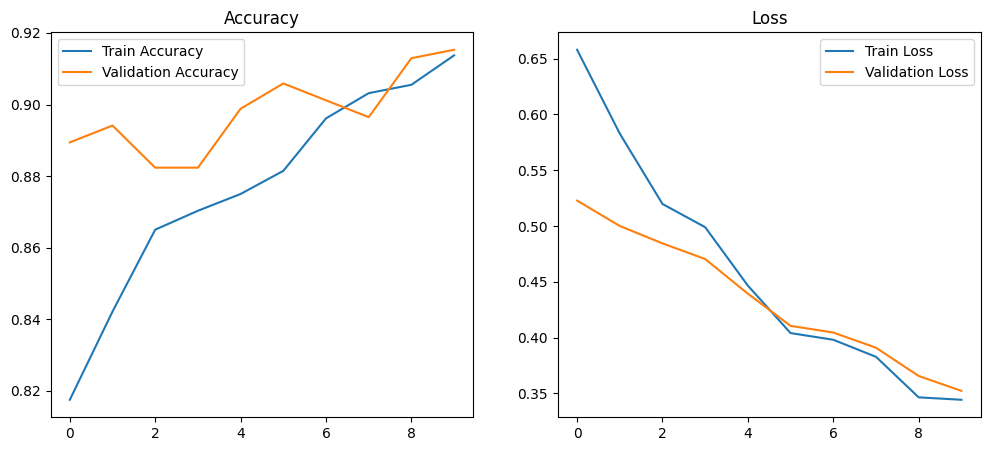

In [10]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [11]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9153 - loss: 0.3522
Validation Accuracy: 91.53%
Validation Loss: 0.3522


**Matriz de Confusión del Modelo de Autenticación de Partes**

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━

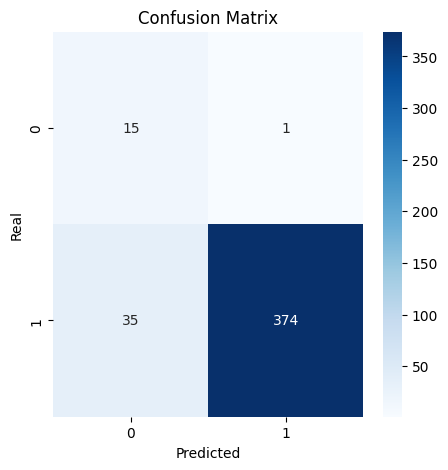

              precision    recall  f1-score   support

           0       0.30      0.94      0.45        16
           1       1.00      0.91      0.95       409

    accuracy                           0.92       425
   macro avg       0.65      0.93      0.70       425
weighted avg       0.97      0.92      0.94       425



In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

 **Evaluación de Umbral Global para Autenticación por Múltiples Partes**

In [24]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
N_SPLITS = 5
SEED = 123
PARTES_POR_CARTERA = 2

tmp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = tmp_ds.class_names
file_paths = np.array(tmp_ds.file_paths)
labels = np.array([int(y.numpy()) for _, y in tmp_ds.unbatch()])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def build_model():
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.RandomFlip("horizontal"),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

thresholds = np.arange(0.70, 0.91, 0.05)

fold_results = []
threshold_results_all = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(file_paths, labels), start=1):

    train_paths = file_paths[train_idx]
    train_labels = labels[train_idx]
    val_paths = file_paths[val_idx]
    val_labels = labels[val_idx]

    train_ds = build_dataset(train_paths, train_labels, training=True)
    val_ds = build_dataset(val_paths, val_labels, training=False)

    class_weights = dict(enumerate(compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_labels),
        y=train_labels
    )))

    model_cv = build_model()

    model_cv.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        verbose=1
    )

    probs_part = model_cv.predict(val_ds, verbose=0).flatten()

    n = len(probs_part) // PARTES_POR_CARTERA

    probs_part = probs_part[:n * PARTES_POR_CARTERA]
    val_labels_cut = val_labels[:n * PARTES_POR_CARTERA]

    prob_matrix = probs_part.reshape(n, PARTES_POR_CARTERA)
    label_matrix = val_labels_cut.reshape(n, PARTES_POR_CARTERA)

    score_global = prob_matrix.min(axis=1)
    y_true_global = label_matrix.max(axis=1)

    best_row = None

    for threshold in thresholds:

        y_pred_global = (score_global >= threshold).astype(int)

        cm = confusion_matrix(y_true_global, y_pred_global, labels=[0, 1])

        row = {
            "fold": fold,
            "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_true_global, y_pred_global),
            "balanced_accuracy": balanced_accuracy_score(y_true_global, y_pred_global),
            "precision_genuine": precision_score(y_true_global, y_pred_global, pos_label=1, zero_division=0),
            "recall_genuine": recall_score(y_true_global, y_pred_global, pos_label=1, zero_division=0),
            "f1_genuine": f1_score(y_true_global, y_pred_global, pos_label=1, zero_division=0),
            "fake_as_genuine": cm[0, 1],
            "genuine_as_fake": cm[1, 0],
            "confusion_matrix": cm.tolist()
        }

        threshold_results_all.append(row)

        if best_row is None:
            best_row = row
        elif (
            row["fake_as_genuine"] < best_row["fake_as_genuine"] or
            (
                row["fake_as_genuine"] == best_row["fake_as_genuine"] and
                row["balanced_accuracy"] > best_row["balanced_accuracy"]
            ) or
            (
                row["fake_as_genuine"] == best_row["fake_as_genuine"] and
                row["balanced_accuracy"] == best_row["balanced_accuracy"] and
                row["threshold"] > best_row["threshold"]
            )
        ):
            best_row = row

    fold_results.append(best_row)

df_thresholds_cv = pd.DataFrame(threshold_results_all)
df_best_folds = pd.DataFrame(fold_results)

display(df_thresholds_cv)
display(df_best_folds)

UMBRAL_GLOBAL_FINAL = df_best_folds["threshold"].median()

print("UMBRAL GLOBAL FINAL:", UMBRAL_GLOBAL_FINAL)
print("PROMEDIO:", df_best_folds["threshold"].mean())
print("MEDIANA:", df_best_folds["threshold"].median())
print("STD:", df_best_folds["threshold"].std())

Found 2129 files belonging to 2 classes.
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.7563 - loss: 0.7376 - val_accuracy: 0.8451 - val_loss: 0.5542
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7616 - loss: 0.6472 - val_accuracy: 0.8850 - val_loss: 0.5193
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8015 - loss: 0.5949 - val_accuracy: 0.8873 - val_loss: 0.4821
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8491 - loss: 0.5481 - val_accuracy: 0.8967 - val_loss: 0.4617
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8708 - loss: 0.5014 - val_accuracy: 0.8944 - val_loss: 0.4398
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8843 - loss: 0.4662 - val_accuracy: 0.9108 - val_loss: 0.4134
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8914 - loss: 0.4341 - val_accuracy: 0.9038 - val_loss: 0.3945
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step -

,fold,threshold,accuracy,balanced_accuracy,precision_genuine,recall_genuine,f1_genuine,fake_as_genuine,genuine_as_fake,confusion_matrix
0,1,0.70,0.563380,0.773171,1.0,0.546341,0.706625,0,93,"[[8, 0], [93, 112]]"
1,1,0.75,0.441315,0.709756,1.0,0.419512,0.591065,0,119,"[[8, 0], [119, 86]]"
2,1,0.80,0.276995,0.624390,1.0,0.248780,0.398438,0,154,"[[8, 0], [154, 51]]"
3,1,0.85,0.112676,0.539024,1.0,0.078049,0.144796,0,189,"[[8, 0], [189, 16]]"
4,1,0.90,0.046948,0.504878,1.0,0.009756,0.019324,0,203,"[[8, 0], [203, 2]]"
5,2,0.70,0.511737,0.746341,1.0,0.492683,0.660131,0,104,"[[8, 0], [104, 101]]"
6,2,0.75,0.436620,0.707317,1.0,0.414634,0.586207,0,120,"[[8, 0], [120, 85]]"
7,2,0.80,0.384977,0.680488,1.0,0.360976,0.530466,0,131,"[[8, 0], [131, 74]]"
8,2,0.85,0.276995,0.624390,1.0,0.248780,0.398438,0,154,"[[8, 0], [154, 51]]"
9,2,0.90,0.112676,0.539024,1.0,0.078049,0.144796,0,189,"[[8, 0], [189, 16]]"


,fold,threshold,accuracy,balanced_accuracy,precision_genuine,recall_genuine,f1_genuine,fake_as_genuine,genuine_as_fake,confusion_matrix
0,1,0.7,0.563380,0.773171,1.0,0.546341,0.706625,0,93,"[[8, 0], [93, 112]]"
1,2,0.7,0.511737,0.746341,1.0,0.492683,0.660131,0,104,"[[8, 0], [104, 101]]"
2,3,0.7,0.572770,0.778049,1.0,0.556098,0.714734,0,91,"[[8, 0], [91, 114]]"
3,4,0.7,0.563380,0.773171,1.0,0.546341,0.706625,0,93,"[[8, 0], [93, 112]]"
4,5,0.7,0.542453,0.762255,1.0,0.524510,0.688103,0,97,"[[8, 0], [97, 107]]"


UMBRAL GLOBAL FINAL: 0.7
PROMEDIO: 0.7
MEDIANA: 0.7
STD: 0.0


**Visualización del Umbral Global por K-Fold**

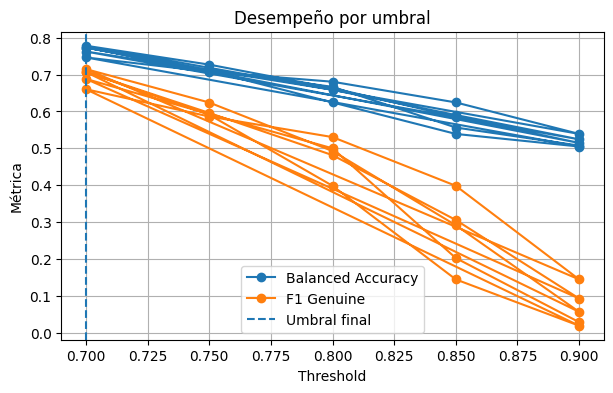

In [26]:
eplt.figure(figsize=(7,4))
plt.plot(df_thresholds_cv["threshold"], df_thresholds_cv["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(df_thresholds_cv["threshold"], df_thresholds_cv["f1_genuine"], marker="o", label="F1 Genuine")
plt.axvline(UMBRAL_GLOBAL_FINAL, linestyle="--", label="Umbral final")
plt.title("Desempeño por umbral")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.legend()
plt.grid(True)
plt.show()